In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

DATA_DIR = Path(".")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

In [6]:
def load_and_merge():
    orders = pd.read_csv("olist_orders_dataset.csv",
    parse_dates=["order_purchase_timestamp","order_delivered_customer_date","order_estimated_delivery_date"])
    items     = pd.read_csv("olist_order_items_dataset.csv")
    customers = pd.read_csv("olist_customers_dataset.csv")
    payments  = pd.read_csv("olist_order_payments_dataset.csv")
    products  = pd.read_csv("olist_products_dataset.csv",usecols=["product_id", "product_category_name"])

    # Some orders have multiple payment rows (instalments) — collapse them
    pay_agg = (
        payments
        .groupby("order_id")
        .agg(
            payment_value=("payment_value", "sum"),
            payment_type=("payment_type",   "first"),
        )
        .reset_index()
    )

    df = (
        orders
        .merge(items,     on="order_id",    how="left")
        .merge(customers, on="customer_id", how="left")
        .merge(pay_agg,   on="order_id",    how="left")
        .merge(products,  on="product_id",  how="left")
    )

    # Keep only real completed orders for revenue analysis
    df = df[df["order_status"].isin(["delivered", "shipped"])].copy()

    df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)
    df["delivery_delay_days"] = (
        df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
    ).dt.days

    return df

df = load_and_merge()
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
df.head(3)

Rows: 111,383  |  Columns: 23


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_type,product_category_name,order_month,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,credit_card,utilidades_domesticas,2017-10,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,boleto,perfumaria,2018-07,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,credit_card,automotivo,2018-08,-18.0


In [ ]:
def basic_metrics(df):
    unique_orders    = df["order_id"].nunique()
    unique_customers = df["customer_unique_id"].nunique()
    total_revenue    = df["payment_value"].sum()
    avg_order_value  = df.groupby("order_id")["payment_value"].sum().mean()

    print(f"Unique orders    : {unique_orders:,}")
    print(f"Unique customers : {unique_customers:,}")
    print(f"Total revenue    : R$ {total_revenue:,.2f}")
    print(f"Avg order value  : R$ {avg_order_value:,.2f}")

    return {
        "unique_orders": unique_orders,
        "unique_customers": unique_customers,
        "total_revenue": total_revenue,
        "avg_order_value": avg_order_value,
    }

metrics = basic_metrics(df)

In [8]:
def basic_metrics(df):
    unique_orders    = df["order_id"].nunique()
    unique_customers = df["customer_unique_id"].nunique()
    total_revenue    = df["payment_value"].sum()
    avg_order_value  = df.groupby("order_id")["payment_value"].sum().mean()

    print(f"Unique orders    : {unique_orders:,}")
    print(f"Unique customers : {unique_customers:,}")
    print(f"Total revenue    : R$ {total_revenue:,.2f}")
    print(f"Avg order value  : R$ {avg_order_value:,.2f}")

    return {
        "unique_orders": unique_orders,
        "unique_customers": unique_customers,
        "total_revenue": total_revenue,
        "avg_order_value": avg_order_value,
    }

metrics = basic_metrics(df)

Unique orders    : 97,585
Unique customers : 94,399
Total revenue    : R$ 19,973,310.58
Avg order value  : R$ 204.68


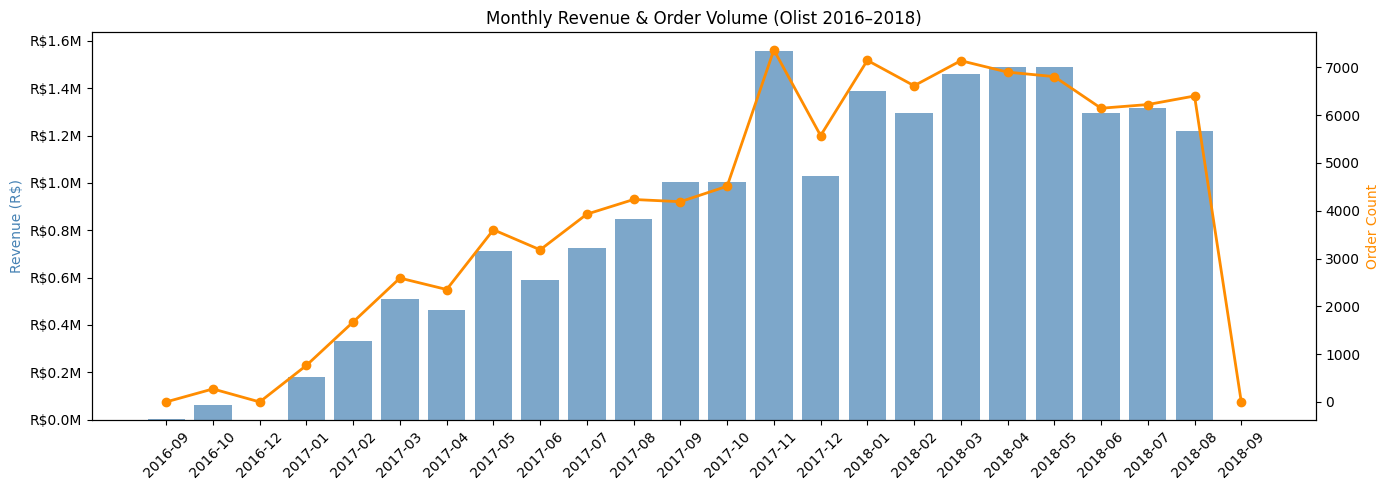

Best month: 2017-11  —  R$ 1,558,120


In [9]:
def monthly_revenue(df):
    order_level = (
        df.groupby(["order_id", "order_month"])["payment_value"]
        .sum()
        .reset_index()
    )
    monthly = (
        order_level
        .groupby("order_month")
        .agg(
            revenue=("payment_value", "sum"),
            order_count=("order_id",  "count"),
        )
        .reset_index()
        .sort_values("order_month")
    )
    return monthly

monthly = monthly_revenue(df)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(monthly["order_month"], monthly["revenue"], color="steelblue", alpha=0.7)
ax1.set_ylabel("Revenue (R$)", color="steelblue")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M"))
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly["order_month"], monthly["order_count"],
         color="darkorange", marker="o", linewidth=2)
ax2.set_ylabel("Order Count", color="darkorange")

plt.title("Monthly Revenue & Order Volume (Olist 2016–2018)")
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "monthly_revenue.png", dpi=150)
plt.show()

best = monthly.loc[monthly["revenue"].idxmax()]
print(f"Best month: {best['order_month']}  —  R$ {best['revenue']:,.0f}")

In [10]:
def new_vs_repeat(df):
    order_dates = (
        df[["order_id", "customer_unique_id", "order_purchase_timestamp"]]
        .drop_duplicates(subset="order_id")
    )
    first_purchase = (
        order_dates
        .groupby("customer_unique_id")["order_purchase_timestamp"]
        .min()
        .rename("first_purchase_date")
        .reset_index()
    )
    order_dates = order_dates.merge(first_purchase, on="customer_unique_id")
    order_dates["customer_type"] = order_dates.apply(
        lambda r: "New" if r["order_purchase_timestamp"] == r["first_purchase_date"]
                  else "Repeat",
        axis=1,
    )
    result = (
        order_dates
        .merge(
            df[["order_id", "payment_value"]].drop_duplicates(subset="order_id"),
            on="order_id"
        )
        .groupby("customer_type")
        .agg(
            order_count=("order_id",       "count"),
            revenue=("payment_value",      "sum"),
            avg_order_value=("payment_value", "mean"),
        )
        .reset_index()
    )
    return result

retention = new_vs_repeat(df)
print(retention.to_string(index=False))

repeat_pct = (
    retention.loc[retention["customer_type"] == "Repeat", "order_count"].values[0]
    / retention["order_count"].sum() * 100
)
print(f"\nRepeat purchase rate: {repeat_pct:.1f}%")
if repeat_pct < 10:
    print("Insight: Repeat rate is critically low. This is a retention problem, not a data error.")

customer_type  order_count     revenue  avg_order_value
          New        94667 15168623.51       160.233067
       Repeat         2918   431052.22       147.721803

Repeat purchase rate: 3.0%
Insight: Repeat rate is critically low. This is a retention problem, not a data error.


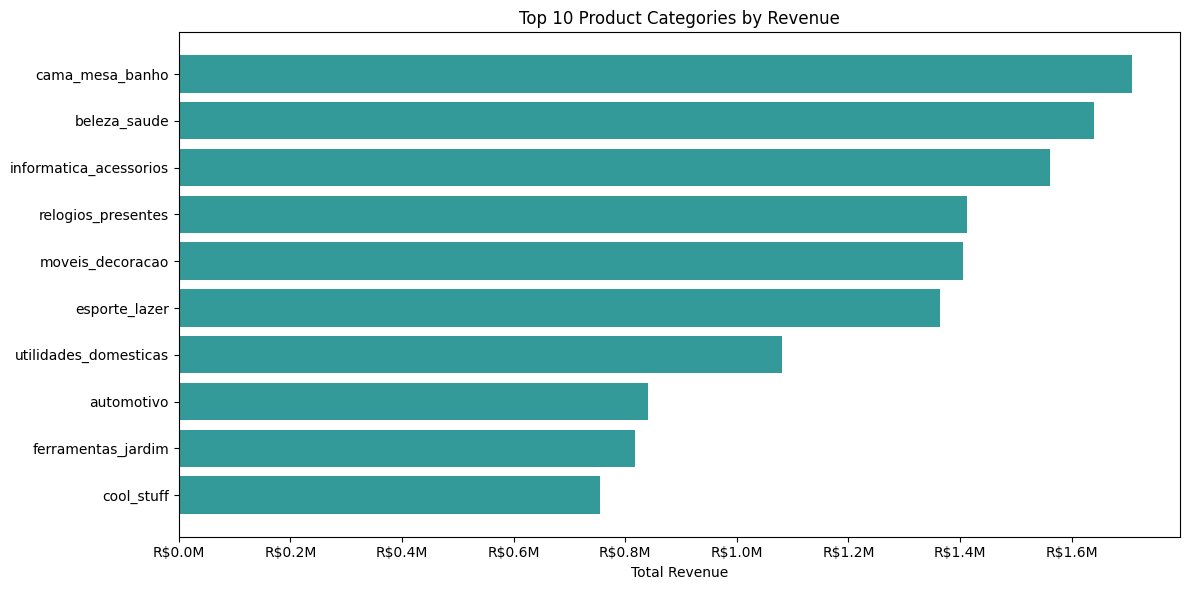

In [11]:
def top_categories(df, n=10):
    result = (
        df.groupby("product_category_name")
        .agg(
            total_revenue=("payment_value", "sum"),
            order_count=("order_id",        "nunique"),
            avg_item_price=("price",        "mean"),
        )
        .reset_index()
        .sort_values("total_revenue", ascending=False)
        .head(n)
    )
    return result

categories = top_categories(df)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(categories["product_category_name"][::-1],
        categories["total_revenue"][::-1],
        color="teal", alpha=0.8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M"))
ax.set_xlabel("Total Revenue")
ax.set_title("Top 10 Product Categories by Revenue")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_categories.png", dpi=150)
plt.show()

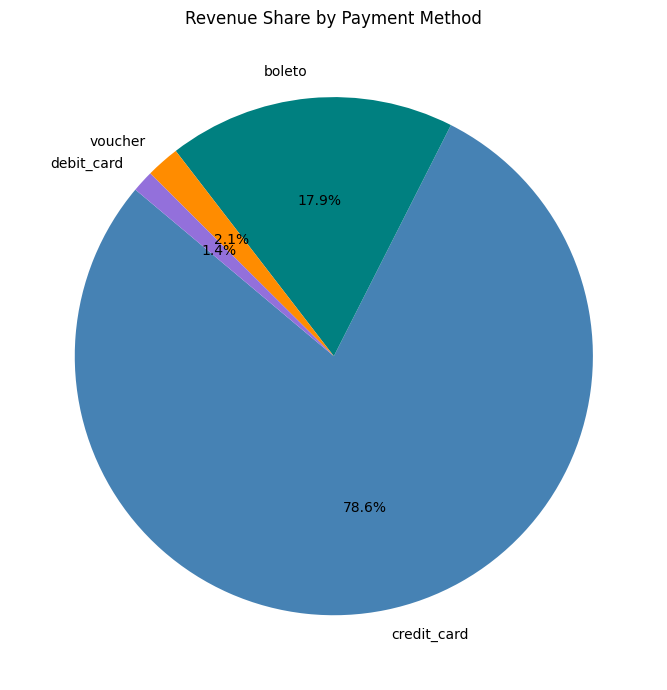

payment_type  order_count  total_revenue  revenue_share_pct
 credit_card        74060    12268529.80               78.6
      boleto        19400     2794160.28               17.9
     voucher         2618      325953.73                2.1
  debit_card         1506      211031.92                1.4


In [12]:
def payment_breakdown(df):
    result = (
        df.drop_duplicates(subset="order_id")
        .groupby("payment_type")
        .agg(
            order_count=("order_id",       "count"),
            total_revenue=("payment_value", "sum"),
        )
        .reset_index()
        .sort_values("total_revenue", ascending=False)
    )
    result["revenue_share_pct"] = (
        result["total_revenue"] / result["total_revenue"].sum() * 100
    ).round(1)
    return result

payments_df = payment_breakdown(df)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(payments_df["total_revenue"],
       labels=payments_df["payment_type"],
       autopct="%1.1f%%",
       startangle=140,
       colors=["steelblue", "teal", "darkorange", "mediumpurple", "gray"])
ax.set_title("Revenue Share by Payment Method")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "payment_methods.png", dpi=150)
plt.show()
print(payments_df.to_string(index=False))

In [13]:
def delivery_performance(df):
    delivered = df[
        (df["order_status"] == "delivered") &
        df["delivery_delay_days"].notna()
    ].drop_duplicates(subset="order_id").copy()

    delivered["delivery_status"] = delivered["delivery_delay_days"].apply(
        lambda d: "Late" if d > 0 else "On Time"
    )

    summary = (
        delivered
        .groupby("delivery_status")["order_id"]
        .count()
        .reset_index()
        .rename(columns={"order_id": "order_count"})
    )
    summary["pct"] = (
        summary["order_count"] / summary["order_count"].sum() * 100
    ).round(1)

    avg_delay = delivered["delivery_delay_days"].mean()
    print(f"Average delivery delta: {avg_delay:.1f} days "
          f"({'late' if avg_delay > 0 else 'early'} vs estimate)")
    print(summary.to_string(index=False))
    return summary

delivery = delivery_performance(df)

Average delivery delta: -11.9 days (early vs estimate)
delivery_status  order_count  pct
           Late         6534  6.8
        On Time        89936 93.2


In [14]:
monthly.to_csv(OUTPUT_DIR / "monthly_metrics.csv",       index=False)
retention.to_csv(OUTPUT_DIR / "new_vs_repeat.csv",       index=False)
categories.to_csv(OUTPUT_DIR / "top_categories.csv",     index=False)
payments_df.to_csv(OUTPUT_DIR / "payment_methods.csv",   index=False)
delivery.to_csv(OUTPUT_DIR / "delivery_performance.csv", index=False)

print("Done. Files saved:")
for f in OUTPUT_DIR.iterdir():
    print(" -", f.name)

Done. Files saved:
 - monthly_metrics.csv
 - top_categories.png
 - monthly_revenue.png
 - payment_methods.png
 - delivery_performance.csv
 - new_vs_repeat.csv
 - payment_methods.csv
 - top_categories.csv
